In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('synthetic_dataset_10000x20.csv')

In [3]:
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


# Basic checks (EDA)

In [4]:
df.shape

(10000, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [6]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


In [7]:
df.isnull().sum()

customer_id              0
age                      0
income                 318
savings                311
monthly_expenses       325
num_dependents           0
credit_score           326
loan_amount              0
loan_term_months         0
employment_years         0
home_ownership           0
education                0
marital_status           0
region                   0
recent_default           0
has_credit_card          0
signup_date              0
signup_dayofweek         0
debt_to_income           0
sin_age                  0
target_default_risk      0
dtype: int64

In [8]:
# checking the target is balanced or not

In [9]:
df['target_default_risk'].value_counts()

target_default_risk
1    5132
0    4868
Name: count, dtype: int64

<Axes: >

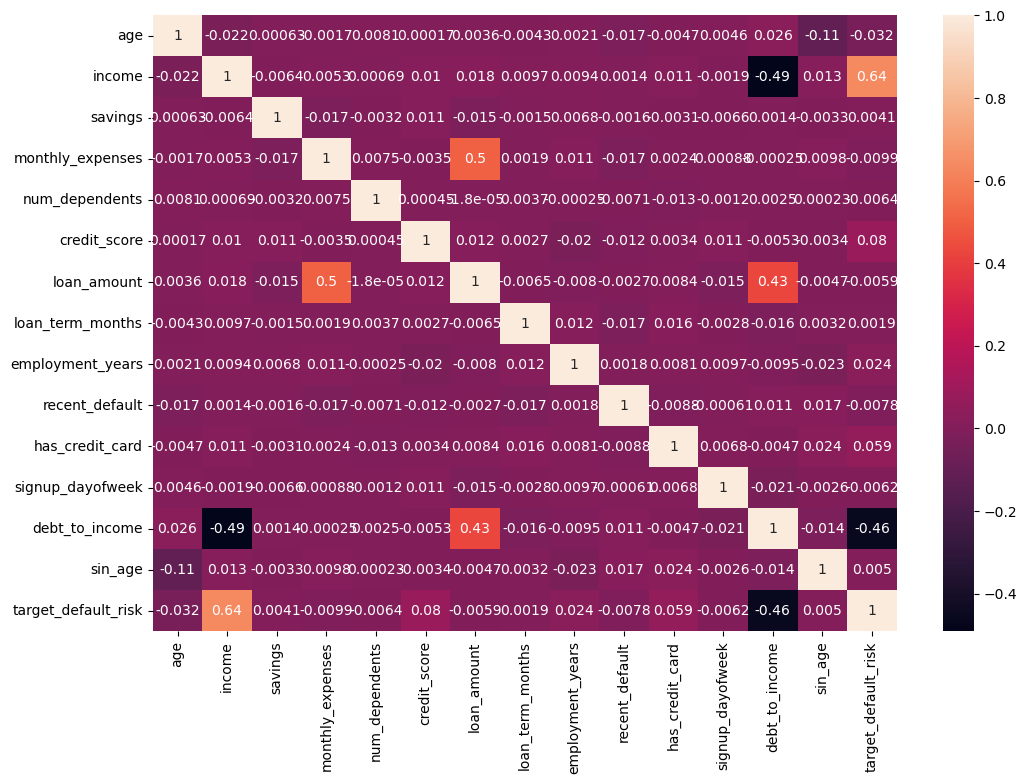

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='income', ylabel='Count'>

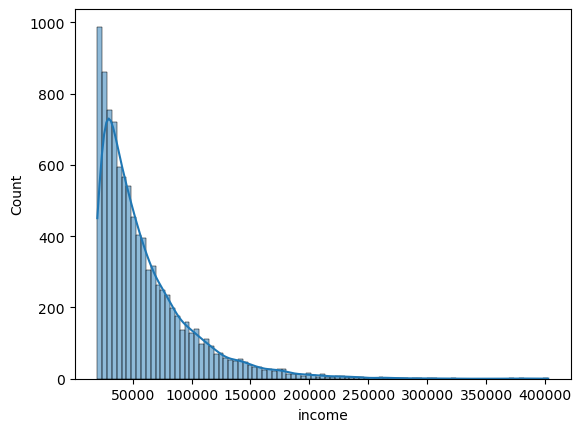

In [11]:
sns.histplot(df['income'],kde=True)

<Axes: xlabel='loan_amount', ylabel='Count'>

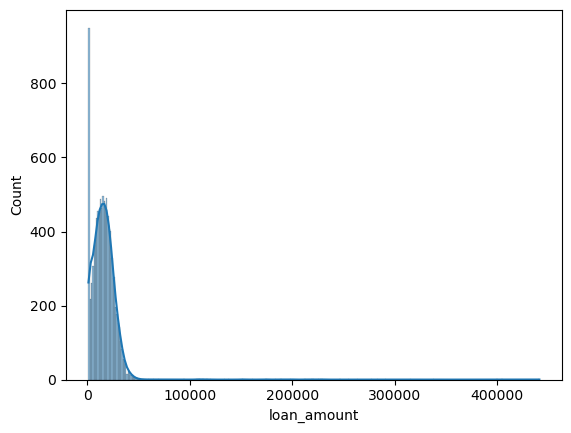

In [12]:
sns.histplot(df['loan_amount'],kde=True)

<Axes: xlabel='credit_score', ylabel='Count'>

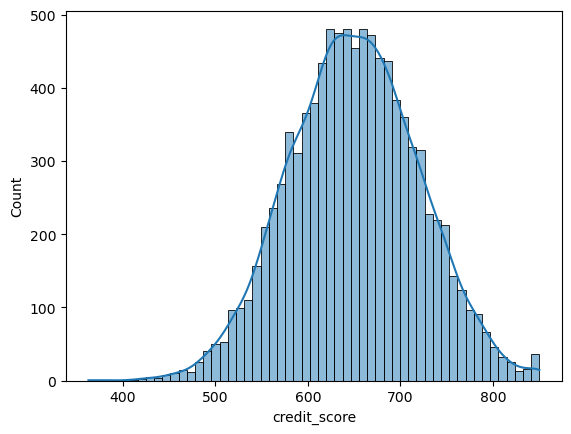

In [13]:
sns.histplot(df['credit_score'],kde=True)

<Axes: xlabel='target_default_risk', ylabel='credit_score'>

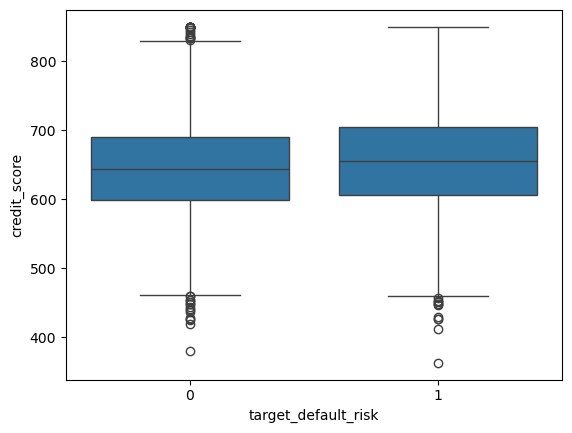

In [14]:
sns.boxplot(x='target_default_risk', y='credit_score', data=df)

## Plot distribution of Numeric features

In [15]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age', 'target_default_risk'],
      dtype='object')

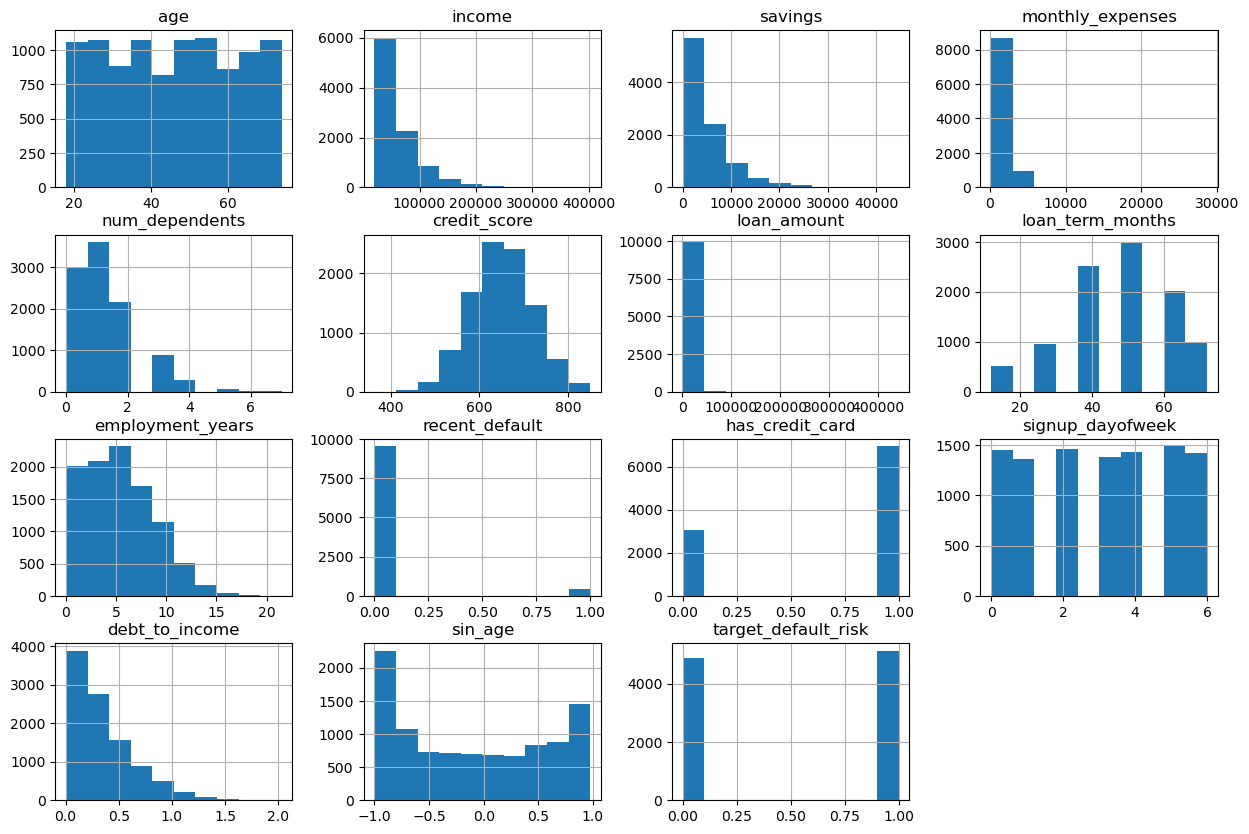

In [16]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols].hist(figsize=(15,10))
plt.show()

In [17]:
# To check outliers

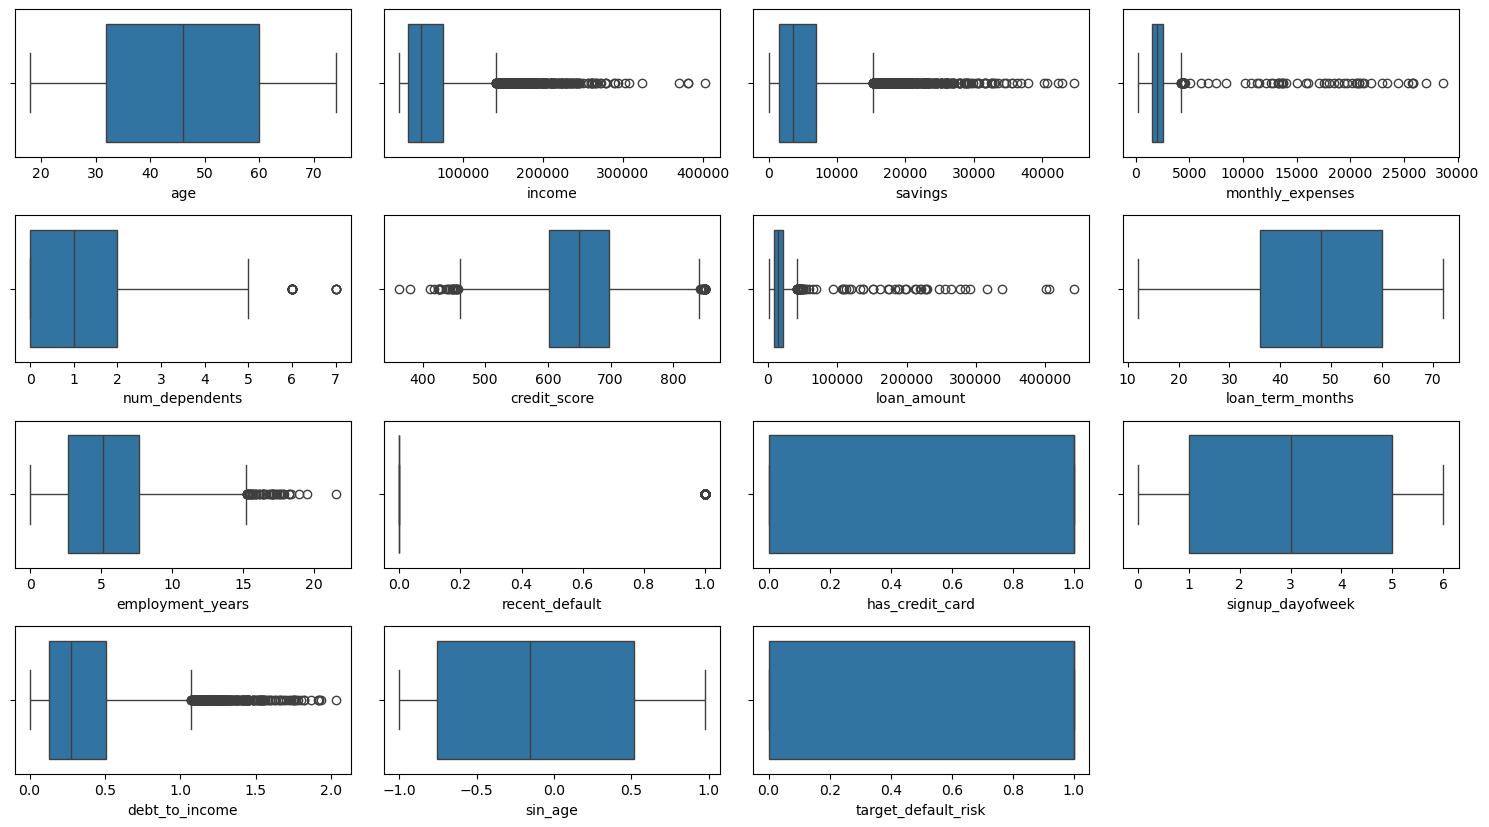

In [18]:
plt.figure(figsize=(15,10))    
for i,col in enumerate(numeric_cols):
    plt.subplot(5,4,i+1)
    sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()

## Categorical variable Analysis

In [19]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['customer_id', 'home_ownership', 'education', 'marital_status',
       'region', 'signup_date'],
      dtype='object')

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(df[col].value_counts())

customer_id
CUST006253    1
CUST001238    1
CUST001308    1
CUST009430    1
CUST000999    1
             ..
CUST002729    1
CUST009598    1
CUST004986    1
CUST006847    1
CUST007271    1
Name: count, Length: 10000, dtype: int64
home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64
education
Bachelors    4443
HS           2546
Masters      1962
Other         500
PhD           462
Bachlors       87
Name: count, dtype: int64
marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64
region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64
signup_date
2018-06-22    14
2021-04-14    13
2021-01-27    13
2021-11-14    13
2022-05-07    12
              ..
2023-04-16     1
2022-05-31     1
2020-03-22     1
2022-07-31     1
2018-11-04     1
Name: count, Length: 1982, dtype: int64


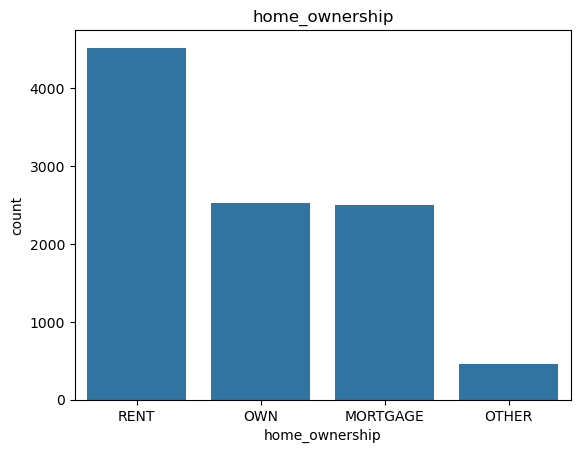

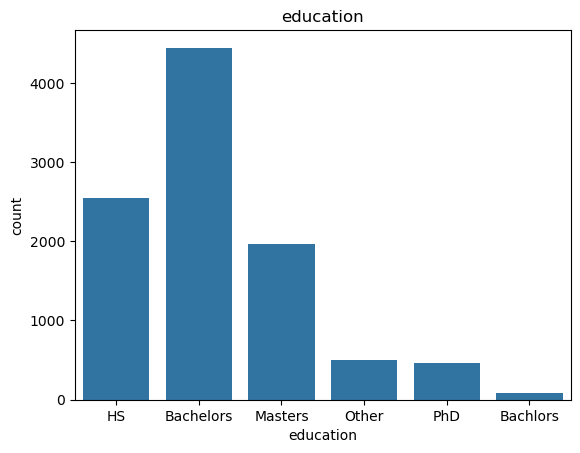

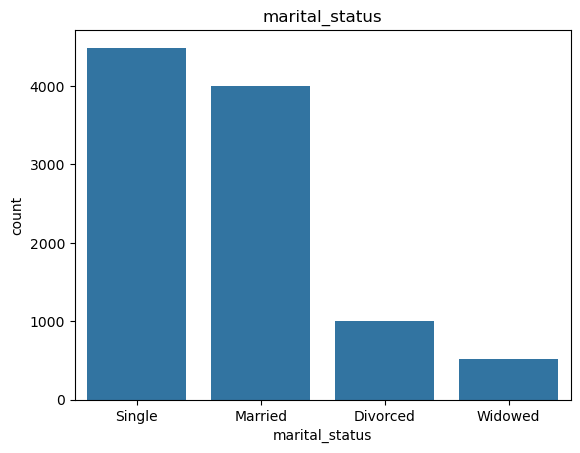

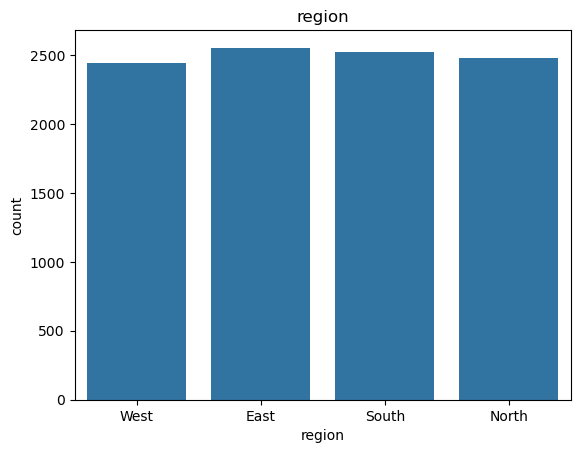

In [21]:
categorical_cols = ['home_ownership','education','marital_status','region']  # customer_id,signup_date has too many unique values, so plotting them creates thousands of bars

for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

# Data Preprocessing

In [22]:
# Handling the missing values 

In [23]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [24]:
df.isnull().sum()

customer_id            0
age                    0
income                 0
savings                0
monthly_expenses       0
num_dependents         0
credit_score           0
loan_amount            0
loan_term_months       0
employment_years       0
home_ownership         0
education              0
marital_status         0
region                 0
recent_default         0
has_credit_card        0
signup_date            0
signup_dayofweek       0
debt_to_income         0
sin_age                0
target_default_risk    0
dtype: int64

In [25]:
# Fixing categorical inconsistencies 

In [26]:
df['education'] = df['education'].replace('Bachlors', 'Bachelors')

In [27]:
df['education'].value_counts()

education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64

In [28]:
# Spliting X and y

In [29]:
X = df.drop('target_default_risk', axis=1)
y = df['target_default_risk']

In [30]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y,test_size=0.2,random_state=42)

In [31]:
X_train = X_train.drop(['customer_id','signup_date'], axis=1)
X_test = X_test.drop(['customer_id','signup_date'], axis=1)

In [32]:
# categorical Nominal columns

In [33]:
cat_cols = ['home_ownership','marital_status','region']

In [34]:
# Categorical Ordinal columns

In [35]:
ord_col = ['education']

In [36]:
# Numerical Columns

In [37]:
num_cols = X_train.select_dtypes(include='number').columns

In [38]:
num_cols

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age'],
      dtype='object')

In [39]:
# Ordinal Encoding

In [40]:
X_train.select_dtypes(include='object').columns

Index(['home_ownership', 'education', 'marital_status', 'region'], dtype='object')

In [41]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['HS','Bachelors','Masters','PhD','Other']])

X_train[['education']] = oe.fit_transform(X_train[['education']])
X_test[['education']] = oe.transform(X_test[['education']])

In [42]:
# One Hot Encoding

In [43]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [44]:
# convert to DataFrame

In [45]:
ohe_cols = ohe.get_feature_names_out(cat_cols)

X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_cols, index=X_test.index)

In [46]:
# Drop original categorical columns

In [47]:
X_train = X_train.drop(cat_cols, axis=1)
X_test = X_test.drop(cat_cols, axis=1)

In [48]:
# merge encoded columns

In [49]:
X_train = pd.concat([X_train, X_train_ohe], axis=1)
X_test = pd.concat([X_test, X_test_ohe], axis=1)

In [50]:
# Scaling Numerical columns

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [52]:
# Creating Useful Features

In [53]:
# Income per Dependent

# If a person has many dependents, their income is effectively distributed among more people
# formula -- income_per_dependent = income / (num_dependents + 1)  #we add +1 so we avoid division by zero

In [54]:
X_train['income_per_dependent'] = X_train['income'] / (X_train['num_dependents'] + 1)
X_test['income_per_dependent'] = X_test['income'] / (X_test['num_dependents'] + 1)

In [55]:
# Savings to income ratio
X_train['savings_to_income'] = X_train['savings'] / X_train['income']
X_test['savings_to_income'] = X_test['savings'] / X_test['income']

In [56]:
# Outlier Treatment

In [57]:
num_cols = X_train.select_dtypes(include='number').columns
num_cols

Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'education', 'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed', 'region_North',
       'region_South', 'region_West', 'income_per_dependent',
       'savings_to_income'],
      dtype='object')

In [58]:
# IQR outer boundaries
# IQR = Q3 - Q1

# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR

In [59]:
# Winsorization / Capping
# Apply capping to all numeric features.

In [60]:
for col in num_cols:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

In [61]:
# values < lower -- replaced by lower
# values > upper -- replaced by upper  This is winsorization

# Model Building

In [62]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# create model
lr = LogisticRegression()

# train model
lr.fit(X_train, y_train)

# predictions
y_pred_lr = lr.predict(X_test)

# evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.9415
Precision: 0.9711340206185567
Recall: 0.9136760426770126
F1 Score: 0.9415292353823088
Confusion Matrix:
 [[941  28]
 [ 89 942]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.97      0.94       969
         1.0       0.97      0.91      0.94      1031

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



In [63]:
# Decision Tree Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# create model
dt = DecisionTreeClassifier()

# train model
dt.fit(X_train, y_train)

# predictions
y_pred_dt = dt.predict(X_test)

# evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.921
Precision: 0.930898321816387
Recall: 0.9146459747817652
F1 Score: 0.9227005870841487
Confusion Matrix:
 [[899  70]
 [ 88 943]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       969
         1.0       0.93      0.91      0.92      1031

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



In [64]:
# SVM Model

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# create model
svm = SVC()

# train model
svm.fit(X_train, y_train)

# predictions
y_pred_svm = svm.predict(X_test)

# evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.9235
Precision: 0.9700214132762313
Recall: 0.8787584869059166
F1 Score: 0.9221374045801527
Confusion Matrix:
 [[941  28]
 [125 906]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.97      0.92       969
         1.0       0.97      0.88      0.92      1031

    accuracy                           0.92      2000
   macro avg       0.93      0.92      0.92      2000
weighted avg       0.93      0.92      0.92      2000



In [65]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# create model
rf = RandomForestClassifier()

# train model
rf.fit(X_train, y_train)

# predictions
y_pred_rf = rf.predict(X_test)

# evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.946
Precision: 0.9647532729103726
Recall: 0.9291949563530553
F1 Score: 0.9466403162055336
Confusion Matrix:
 [[934  35]
 [ 73 958]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.96      0.95       969
         1.0       0.96      0.93      0.95      1031

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



In [66]:
# XGBoost Model

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# create model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# train model
xgb.fit(X_train, y_train)

# predictions
y_pred_xgb = xgb.predict(X_test)

# evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm)

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

C:\Users\praba\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:58:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9615
Precision: 0.9685658153241651
Recall: 0.95635305528613
F1 Score: 0.9624206930209859
Confusion Matrix:
 [[937  32]
 [ 45 986]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.97      0.96       969
         1.0       0.97      0.96      0.96      1031

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



## Hyperparameter Tuning

In [67]:
# RandomForest Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100,200,300,400,500],
    'max_depth': [None,10,20,30,40],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

rf_random = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Tuned RF Accuracy: 0.9445


In [ ]:
# XGBoost Hyperparameter Tuning

In [69]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_dist_xgb = {
    'n_estimators': [300,500,700],
    'max_depth': [4,5,6,7,8],
    'learning_rate': [0.01,0.03,0.05,0.1],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'gamma': [0,0.1,0.2]
}

xgb_random = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

In [70]:
print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))

Tuned XGBoost Accuracy: 0.9595


In [110]:
print(xgb_random.best_params_)  # this combination may reduce the accuaracy

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}


In [111]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

Accuracy: 0.958


In [112]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [300,500,700],
    'max_depth': [5,6,7,8],
    'learning_rate': [0.01,0.03,0.05],
    'subsample': [0.8,0.9,1],
    'colsample_bytree': [0.8,0.9,1],
    'gamma': [0,0.1,0.2],
    'min_child_weight': [1,3,5]
}

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

KeyboardInterrupt: 

# 